**Conditional Workflows using LLMs**

In [3]:
import operator
from typing import Annotated, List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv


In [2]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_retries=2,
)

In [4]:
# --- Structured Output Models ---
class SentimentResult(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The overall sentiment of the text")

class DiagnosisResult(BaseModel):
    issue_type: str = Field(description="The core problem (e.g., Billing, Bug, UX)")
    user_tone: str = Field(description="Emotional state (e.g., Angry, Frustrated, Sarcastic)")
    urgency: Literal["high", "medium", "low"] = Field(description="How quickly this needs a fix")

# --- State Definition ---
class SupportState(TypedDict):
    user_input: str
    sentiment: str
    diagnosis: DiagnosisResult
    final_response: str

In [5]:
def analyze_sentiment(state: SupportState):
    structured_llm = llm.with_structured_output(SentimentResult)
    result = structured_llm.invoke(f"Analyze the sentiment of this user feedback: {state['user_input']}")
    return {"sentiment": result.sentiment}

def handle_positive(state: SupportState):
    prompt = f"Write a brief, warm thank-you note for this positive feedback: {state['user_input']}"
    response = llm.invoke(prompt).content
    return {"final_response": response}

def run_diagnosis(state: SupportState):
    diagnostic_llm = llm.with_structured_output(DiagnosisResult)
    prompt = f"Diagnose the following negative feedback to find issue_type, tone, and urgency: {state['user_input']}"
    diagnosis = diagnostic_llm.invoke(prompt)
    return {"diagnosis": diagnosis}

def handle_negative_response(state: SupportState):
    d = state['diagnosis']
    prompt = (
        f"Draft a support response. Context: Issue is {d.issue_type}, "
        f"User is {d.user_tone}, Urgency is {d.urgency}. "
        f"Original text: {state['user_input']}"
    )
    response = llm.invoke(prompt).content
    return {"final_response": response}

In [6]:
#define the router
def route_sentiment(state: SupportState) -> Literal["pos_path", "neg_path"]:
    if state["sentiment"] == "positive":
        return "pos_path"
    return "neg_path"

builder = StateGraph(SupportState)

In [7]:
# Add Nodes
builder.add_node("analyze_sentiment", analyze_sentiment)
builder.add_node("handle_positive", handle_positive)
builder.add_node("run_diagnosis", run_diagnosis)
builder.add_node("handle_negative_response", handle_negative_response)

# Define Logic
builder.add_edge(START, "analyze_sentiment")

# Conditional Routing
builder.add_conditional_edges(
    "analyze_sentiment",
    route_sentiment,
    {
        "pos_path": "handle_positive",
        "neg_path": "run_diagnosis"
    }
)

# Negative path has an extra sequential step
builder.add_edge("run_diagnosis", "handle_negative_response")

# Both paths end at END
builder.add_edge("handle_positive", END)
builder.add_edge("handle_negative_response", END)

graph = builder.compile()

In [8]:
# Test Case 1: Negative
input_neg = {"user_input": "I am so annoyed that my payment failed three times today! Fix this immediately!"}
result_neg = graph.invoke(input_neg)

print(f"Sentiment: {result_neg['sentiment']}")
if 'diagnosis' in result_neg:
    print(f"Diagnosis: {result_neg['diagnosis']}")
print(f"Response: {result_neg['final_response']}")

Sentiment: negative
Diagnosis: issue_type='Billing' user_tone='Angry' urgency='high'
Response: Dear valued customer,

I apologize sincerely for the frustration and inconvenience caused by the repeated payment failures you've experienced today. I understand how annoying this must be for you, and I'm here to help resolve the issue as quickly as possible.

I want to assure you that I'm taking immediate action to investigate and rectify the problem. Can you please provide me with your order/reference number or any other relevant details so I can look into this further? This will enable me to expedite the resolution process and prevent any future occurrences.

In the meantime, I'd like to offer you a few options to complete your payment successfully:

1. **Alternative payment methods**: Would you like to try a different payment method, such as a credit card or PayPal?
2. **Retry payment**: If you'd prefer to stick with your original payment method, I can try to process the payment again.
3.

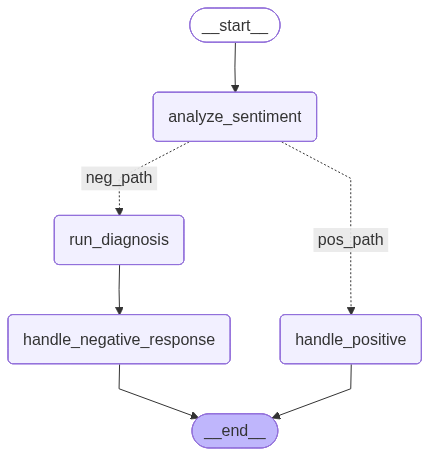

In [9]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())